# S1 — Forecast-to-Inventory

**Distributional demand forecasting → newsvendor → multi-echelon MILP, evaluated by fill rate and rupees.**

The point of this project is *not* the forecaster. It is the **decision-consistent rolling-origin backtest**:
every candidate model feeds the *same* replenishment policy, the plan is executed against *actual* demand
in a simulator, and models are compared on service level and cost — never on RMSE.

---

### Pipeline

```
raw panel
  -> features (leak-free, target = forward L+R day demand sum)
  -> quantile forecaster (XGBoost GPU, multi-quantile)   [refit at each origin]
  -> policy: newsvendor order-up-to  OR  multi-echelon MILP (rolling horizon)
  -> simulator: real demand, real lead times, DC allocation under scarcity
  -> metrics: fill rate, INR cost, inventory value
```

### Why the target is a forward *sum*
The newsvendor needs the distribution of demand over the **protection interval** (lead time + review period),
not the distribution of daily demand. Quantiles do not add, so you cannot forecast daily quantiles and sum them.
We forecast the aggregated protection-interval demand directly. This is the single most important modelling
decision in the notebook and the one most portfolio projects get wrong.

### Runtime
`FAST_MODE = True` finishes in about a minute and exercises every code path. Turn it off for the real run.

In [16]:
# Colab setup. Safe to re-run.
import subprocess, sys, importlib

def ensure(pkg, imp=None):
    try:
        importlib.import_module(imp or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

ensure("xgboost")
ensure("pulp")
ensure("highspy")
ensure("pyarrow")

import numpy as np
import pandas as pd
import xgboost as xgb

print("xgboost", xgb.__version__)
print("pandas", pd.__version__)

xgboost 3.3.0
pandas 2.2.2


In [17]:
# GPU detection. XGBoost 2.x uses device="cuda"; we verify with a throwaway fit
# rather than trusting nvidia-smi, because Colab sometimes exposes a GPU that
# the installed xgboost wheel was not built against.
def detect_device():
    try:
        X = np.random.rand(64, 4)
        y = np.random.rand(64)
        m = xgb.XGBRegressor(n_estimators=2, tree_method="hist", device="cuda", verbosity=0)
        m.fit(X, y)
        m.predict(X)
        return "cuda"
    except Exception as e:
        print(f"GPU unavailable ({type(e).__name__}), falling back to CPU.")
        return "cpu"

DEVICE = detect_device()
print("device:", DEVICE)

device: cuda


## Config

Every knob lives here. `FAST_MODE` is the one that matters day to day — you will run this
notebook fifty times while debugging the backtest loop, and a two-hour cycle time kills the project.

In [18]:
from dataclasses import dataclass, field

FAST_MODE = False   # True = ~1 min smoke test; False = the real run

@dataclass
class Config:
    # --- scale ---
    n_items: int = 6 if FAST_MODE else 40
    n_stores: int = 3 if FAST_MODE else 6
    n_origins: int = 3 if FAST_MODE else 12       # model refits; sim length = n_origins * origin_step
    origin_step: int = 28                          # days between model refits

    # --- supply chain ---
    review_period: int = 7                         # days between store replenishment reviews
    lead_time_store: int = 7                       # DC -> store transit
    lead_time_dc: int = 14                         # supplier -> DC transit
    dc_capacity_units: int = 100_000               # per-SKU DC cap (loose by default)

    # --- economics ---
    gross_margin: float = 0.30                     # (price - cost) / price
    annual_holding_rate: float = 0.25              # capital + storage + shrink + markdown risk
    # Per SKU LINE, not per purchase order. The model is decomposed per SKU, so a
    # per-PO cost charged inside each SKU's problem would be counted n_items times
    # and would swamp holding and lost margin. If you re-couple SKUs into a joint
    # model, move this to a true per-PO fixed cost and raise it accordingly.
    fixed_order_cost_inr: float = 250.0
    target_fill_rate: float = 0.95                 # the service-level CONSTRAINT
    usd_to_inr: float = 87.0                       # <-- see the currency note below

    # --- forecasting ---
    quantiles: tuple = (0.50, 0.80, 0.90, 0.95, 0.975, 0.99)
    n_estimators: int = 200 if FAST_MODE else 600
    learning_rate: float = 0.06
    max_depth: int = 6

    @property
    def protection_interval(self) -> int:
        """Horizon the newsvendor must cover: lead time + review period."""
        return self.lead_time_store + self.review_period

    @property
    def sim_days(self) -> int:
        return self.n_origins * self.origin_step

CFG = Config()
H = CFG.protection_interval
print(f"protection interval H = {H} days | simulation length = {CFG.sim_days} days")

protection interval H = 14 days | simulation length = 336 days


### Currency note — read this before you put a number on your resume

M5 is Walmart **US** data, priced in USD. Converting at a flat rate and calling the result
"rupees" is defensible only if you say so out loud. Silently relabelling dollars as rupees is
exactly the kind of thing an ops interviewer catches, and it costs you the whole story.

Three honest options:
1. Use M5, convert explicitly, and label every figure "USD converted at ₹87/$" (what this notebook does).
2. Use the synthetic generator below, which is denominated in INR natively at Indian retail price points.
3. Find an Indian retail dataset and accept the smaller scale.

## Data

Three sources, same downstream schema. Start with `synthetic` so the notebook runs end to end
on first execution with zero setup, then switch to `m5` once the pipeline is green.

**Required schema:** `date, store_id, item_id, sales, sell_price`

### Datasets worth using

| Dataset | Where | Why / why not |
|---|---|---|
| **M5 Forecasting — Accuracy** | Kaggle `m5-forecasting-accuracy` | **Primary choice.** 30,490 SKU-store series, 1,941 days, real `sell_price`, calendar + SNAP events. The prices are what make newsvendor economics possible — most retail datasets omit them. Needs a Kaggle API token. |
| **Corporación Favorita** | Kaggle `favorita-grocery-sales-forecasting` | Good second option: promotions and oil price as exogenous drivers. Prices absent, so you must assume margins. |
| **Online Retail II** | UCI, direct download, no auth | Fallback if Kaggle auth is a hassle. Real unit prices in GBP, but it is UK e-commerce transactions, not store-SKU-day retail — you must aggregate, and store structure is thin. |
| **Rossmann Store Sales** | Kaggle | **Avoid.** Store-level revenue only, no SKU granularity, so there is nothing to replenish. |

In [19]:
DATA_SOURCE = "synthetic"   # "synthetic" | "m5" | "csv"

In [20]:
def make_synthetic(cfg: Config, n_days: int = 1500, seed: int = 7) -> pd.DataFrame:
    """
    INR-denominated store-SKU-day panel with the failure modes that make this problem hard:
    weekly + annual seasonality, trend, intermittency, price elasticity, and promo spikes.
    Deliberately not clean — a policy that only works on smooth demand is not worth reporting.
    """
    rng = np.random.default_rng(seed)
    dates = pd.date_range("2021-01-01", periods=n_days, freq="D")
    dow = dates.dayofweek.values
    doy = dates.dayofyear.values

    rows = []
    for i in range(cfg.n_items):
        base_price = float(rng.choice([49, 99, 149, 249, 399, 599, 899]))
        elasticity = rng.uniform(-2.2, -0.8)
        intermittency = rng.uniform(0.0, 0.45)          # share of structural zero days
        annual_amp = rng.uniform(0.05, 0.40)
        annual_phase = rng.uniform(0, 2 * np.pi)
        dow_profile = rng.uniform(0.65, 1.45, size=7)
        dow_profile /= dow_profile.mean()

        # promo calendar: ~6% of days discounted 10-35%
        promo = rng.random(n_days) < 0.06
        discount = np.where(promo, rng.uniform(0.10, 0.35, n_days), 0.0)
        price = base_price * (1 - discount)

        for s in range(cfg.n_stores):
            store_mult = rng.uniform(0.5, 2.0)
            base_rate = rng.uniform(0.8, 9.0) * store_mult
            trend = np.linspace(1.0, rng.uniform(0.75, 1.35), n_days)
            season = 1 + annual_amp * np.sin(2 * np.pi * doy / 365.25 + annual_phase)
            price_eff = (price / base_price) ** elasticity
            lam = base_rate * trend * season * dow_profile[dow] * price_eff
            lam = np.clip(lam, 0.01, None)

            sales = rng.poisson(lam)
            sales = np.where(rng.random(n_days) < intermittency, 0, sales)

            rows.append(pd.DataFrame({
                "date": dates,
                "store_id": f"ST_{s:02d}",
                "item_id": f"SKU_{i:03d}",
                "sales": sales.astype(np.int32),
                "sell_price": price.astype(np.float32),
            }))
    return pd.concat(rows, ignore_index=True)


# ---- Kaggle credentials (new-style token) ----
KAGGLE_TOKEN = "KGAT_10a8857ba43e0a9feaccadc62a31257d"   # your NEW token after rotating
# ----------------------------------------------

def load_m5(cfg: Config) -> pd.DataFrame:
    import os, glob, pathlib

    tok = KAGGLE_TOKEN.strip()
    os.environ["KAGGLE_API_TOKEN"] = tok
    # also write the file the client reads automatically, as a belt-and-braces fallback
    kdir = pathlib.Path.home() / ".kaggle"
    kdir.mkdir(parents=True, exist_ok=True)
    (kdir / "access_token").write_text(tok)
    os.chmod(kdir / "access_token", 0o600)
    # a stale kaggle.json takes precedence over the token -- remove it
    (kdir / "kaggle.json").unlink(missing_ok=True)

    if not glob.glob("m5/sales_train_validation.csv"):
        # the KGAT_ token format needs a recent client
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "kaggle"], check=True)
        r = subprocess.run(["kaggle", "competitions", "download", "-c",
                            "m5-forecasting-accuracy", "-p", "m5"],
                           capture_output=True, text=True)
        if r.returncode != 0:
            msg = (r.stderr or "") + (r.stdout or "")
            if "403" in msg or "Forbidden" in msg:
                raise RuntimeError(
                    "403: credentials OK, but you have not accepted the competition rules. "
                    "Open https://www.kaggle.com/competitions/m5-forecasting-accuracy, "
                    "click 'Join Competition', then rerun.")
            if "401" in msg or "Unauthorized" in msg:
                raise RuntimeError(f"401: token rejected. Regenerate it.\n{msg[:400]}")
            raise RuntimeError(f"Kaggle download failed:\n{msg[:800]}")
        subprocess.run(["unzip", "-q", "-o", "m5/m5-forecasting-accuracy.zip", "-d", "m5"],
                       check=True)

    sales = pd.read_csv("m5/sales_train_validation.csv")
    calendar = pd.read_csv("m5/calendar.csv", parse_dates=["date"])
    prices = pd.read_csv("m5/sell_prices.csv")

    # pick the busiest stores, then the busiest SKUs within them
    day_cols = [c for c in sales.columns if c.startswith("d_")]
    sales["_tot"] = sales[day_cols].sum(axis=1)
    top_stores = (sales.groupby("store_id")["_tot"].sum()
                  .nlargest(cfg.n_stores).index.tolist())
    sales = sales[sales.store_id.isin(top_stores)]
    top_items = (sales.groupby("item_id")["_tot"].sum()
                 .nlargest(cfg.n_items).index.tolist())
    sales = sales[sales.item_id.isin(top_items)].drop(columns="_tot")

    long = sales.melt(
        id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
        value_vars=day_cols, var_name="d", value_name="sales")
    long = long.merge(calendar[["d", "date", "wm_yr_wk"]], on="d", how="left")
    long = long.merge(prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")

    long = long.dropna(subset=["sell_price"])          # pre-launch weeks have no price
    long["sell_price"] = long["sell_price"] * cfg.usd_to_inr   # explicit USD -> INR
    return long[["date", "store_id", "item_id", "sales", "sell_price"]].reset_index(drop=True)

def load_csv() -> pd.DataFrame:
    from google.colab import files
    up = files.upload()
    df = pd.read_csv(list(up.keys())[0], parse_dates=["date"])
    need = {"date", "store_id", "item_id", "sales", "sell_price"}
    missing = need - set(df.columns)
    if missing:
        raise ValueError(f"CSV is missing required columns: {missing}")
    return df

In [21]:
import subprocess
print(subprocess.run(["kaggle", "competitions", "list"],
                     capture_output=True, text=True).stdout[:400])

401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/ListCompetitions



In [22]:
if DATA_SOURCE == "synthetic":
    # 1500 days leaves ~1160 days of history before the simulation window opens,
    # comfortably clearing the history assertion in the backtest cell.
    panel = make_synthetic(CFG, n_days=1500)
elif DATA_SOURCE == "m5":
    panel = load_m5(CFG)
else:
    panel = load_csv()

panel = panel.sort_values(["store_id", "item_id", "date"]).reset_index(drop=True)
panel["sales"] = panel["sales"].astype(np.float32)

print(f"rows            : {len(panel):,}")
print(f"date range      : {panel.date.min().date()} -> {panel.date.max().date()}")
print(f"series          : {panel.groupby(['store_id','item_id']).ngroups}")
print(f"zero-sales share: {(panel.sales == 0).mean():.1%}")
panel.head()

rows            : 360,000
date range      : 2021-01-01 -> 2025-02-08
series          : 240
zero-sales share: 27.6%


,date,store_id,item_id,sales,sell_price
0,2021-01-01,ST_00,SKU_000,5.0,899.0
1,2021-01-02,ST_00,SKU_000,0.0,899.0
2,2021-01-03,ST_00,SKU_000,4.0,899.0
3,2021-01-04,ST_00,SKU_000,0.0,899.0
4,2021-01-05,ST_00,SKU_000,1.0,899.0


## Features

**The target is the forward sum of sales over the next `H = lead_time + review_period` days.**
Predicting from origin `t`, everything in the feature row must be observable at `t` — so trailing
windows may include day `t` itself but nothing after it. The target uses only days `t+1 … t+H`.
There is no overlap, hence no leakage.

This also removes the recursive-forecasting problem entirely. There is no need to feed predictions
back in, because we never predict a daily value.

In [23]:
KEY = ["store_id", "item_id"]

def build_features(df: pd.DataFrame, horizon: int) -> pd.DataFrame:
    df = df.sort_values(KEY + ["date"]).copy()
    g = df.groupby(KEY, observed=True)["sales"]

    # --- target: sum of sales over (t, t+horizon] ---
    # rolling(h).sum() at index t+h equals sum over (t, t+h]; shift(-h) moves it back to t.
    df["y"] = g.transform(lambda s: s.rolling(horizon).sum().shift(-horizon))

    # --- trailing demand levels (all observable at t) ---
    for w in (7, 14, 28, 56, 112):
        df[f"roll_mean_{w}"] = g.transform(lambda s, w=w: s.rolling(w, min_periods=2).mean())
        df[f"roll_std_{w}"] = g.transform(lambda s, w=w: s.rolling(w, min_periods=2).std())
    # trailing sum over exactly one protection interval: the strongest single predictor,
    # because it is the same quantity as the target, one interval earlier.
    df["roll_sum_H"] = g.transform(lambda s: s.rolling(horizon, min_periods=1).sum())
    df["roll_sum_H_lag"] = g.transform(lambda s: s.rolling(horizon, min_periods=1).sum().shift(horizon))
    df["roll_max_28"] = g.transform(lambda s: s.rolling(28, min_periods=2).max())

    # --- lags ---
    for l in (1, 7, 14, 28, 364):
        df[f"lag_{l}"] = g.shift(l)

    # --- intermittency: how spiky is this series, and how long since it last moved ---
    df["zero_share_28"] = g.transform(lambda s: (s == 0).rolling(28, min_periods=2).mean())
    df["days_since_sale"] = (
        df.groupby(KEY, observed=True)["sales"]
          .transform(lambda s: s.groupby(s.gt(0).cumsum()).cumcount())
    )

    # --- coefficient of variation drives how much safety stock the quantiles will imply ---
    df["cv_28"] = df["roll_std_28"] / df["roll_mean_28"].replace(0, np.nan)

    # --- price ---
    gp = df.groupby(KEY, observed=True)["sell_price"]
    df["price_roll_28"] = gp.transform(lambda s: s.rolling(28, min_periods=1).mean())
    df["price_rel"] = df["sell_price"] / df["price_roll_28"]
    df["price_chg_7"] = df["sell_price"] / gp.shift(7) - 1.0

    # --- calendar ---
    df["dow"] = df.date.dt.dayofweek
    df["month"] = df.date.dt.month
    df["weekofyear"] = df.date.dt.isocalendar().week.astype(int)
    df["day_of_month"] = df.date.dt.day

    # --- entity codes (tree models handle these fine as integers) ---
    df["store_code"] = df.store_id.astype("category").cat.codes
    df["item_code"] = df.item_id.astype("category").cat.codes

    return df


FEATURES = [
    "roll_mean_7", "roll_mean_14", "roll_mean_28", "roll_mean_56", "roll_mean_112",
    "roll_std_7", "roll_std_14", "roll_std_28", "roll_std_56", "roll_std_112",
    "roll_sum_H", "roll_sum_H_lag", "roll_max_28",
    "lag_1", "lag_7", "lag_14", "lag_28", "lag_364",
    "zero_share_28", "days_since_sale", "cv_28",
    "sell_price", "price_rel", "price_chg_7",
    "dow", "month", "weekofyear", "day_of_month",
    "store_code", "item_code",
]

feat = build_features(panel, H)
print(f"feature rows: {len(feat):,}  |  usable targets: {feat.y.notna().sum():,}")

feature rows: 360,000  |  usable targets: 356,640


### Leakage assertion

Cheap, and it has caught real bugs. If the target at origin `t` could be reconstructed from
features at `t`, the correlation between `y` and a *shifted* copy of itself would be suspiciously
perfect. Here we assert the plain structural property instead: the last `H` rows of every series
must have a null target, because their future does not exist yet.

In [24]:
tail_nulls = feat.groupby(KEY, observed=True)["y"].apply(lambda s: s.tail(H).isna().all())
assert tail_nulls.all(), "Target is defined past the end of the series — check the shift direction."
print(f"OK: final {H} rows of all {len(tail_nulls)} series have an undefined target, as expected.")

OK: final 14 rows of all 240 series have an undefined target, as expected.


## Quantile forecaster

XGBoost with `reg:quantileerror` fits **all quantiles in a single model**, which is both faster
and gives better-behaved (less crossing) quantile curves than fitting six independent models.
If the installed build cannot do multi-quantile on GPU we fall back to a per-quantile loop.

The baseline is a seasonal-naive quantile model: empirical quantiles of the trailing
protection-interval sums. It is not a strawman — on intermittent retail demand it is genuinely
hard to beat, which is the point of including it.

In [25]:
from typing import Protocol

class Forecaster(Protocol):
    name: str
    def fit(self, train: pd.DataFrame): ...
    def predict_quantiles(self, rows: pd.DataFrame) -> np.ndarray: ...
        # -> (n_rows, n_quantiles), columns ordered as CFG.quantiles


class XGBQuantile:
    name = "xgb_quantile"

    def __init__(self, cfg: Config, device: str):
        self.cfg, self.device = cfg, device
        self.models, self.multi = None, True

    def fit(self, train: pd.DataFrame):
        X = train[FEATURES].to_numpy(np.float32)
        y = train["y"].to_numpy(np.float32)
        qs = np.array(self.cfg.quantiles, dtype=np.float32)
        common = dict(n_estimators=self.cfg.n_estimators, learning_rate=self.cfg.learning_rate,
                      max_depth=self.cfg.max_depth, subsample=0.85, colsample_bytree=0.85,
                      min_child_weight=5, tree_method="hist", device=self.device, verbosity=0)
        try:
            m = xgb.XGBRegressor(objective="reg:quantileerror", quantile_alpha=qs, **common)
            m.fit(X, y)
            self.models, self.multi = m, True
        except Exception as e:
            print(f"  multi-quantile unavailable ({type(e).__name__}); looping per quantile")
            self.multi = False
            self.models = []
            for q in qs:
                mi = xgb.XGBRegressor(objective="reg:quantileerror",
                                      quantile_alpha=float(q), **common)
                mi.fit(X, y)
                self.models.append(mi)
        return self

    def predict_quantiles(self, rows: pd.DataFrame) -> np.ndarray:
        X = rows[FEATURES].to_numpy(np.float32)
        if self.multi:
            p = np.asarray(self.models.predict(X))
            if p.ndim == 1:
                p = p.reshape(-1, 1)
        else:
            p = np.column_stack([m.predict(X) for m in self.models])
        p = np.clip(p, 0.0, None)
        # enforce monotonicity across quantiles — crossing is rare but poisons the newsvendor
        return np.maximum.accumulate(p, axis=1)


class SeasonalNaiveQuantile:
    """Empirical quantiles of the trailing H-day sums. No training, no features, hard to beat."""
    name = "seasonal_naive"

    def __init__(self, cfg: Config, lookback_intervals: int = 12):
        self.cfg = cfg
        self.lookback = lookback_intervals
        self.hist = None

    def fit(self, train: pd.DataFrame):
        # keep the most recent `lookback` observed interval-sums per series
        self.hist = (train.dropna(subset=["y"])
                          .sort_values("date")
                          .groupby(KEY, observed=True)["y"]
                          .apply(lambda s: s.tail(self.lookback * 1).to_numpy())
                          .to_dict())
        return self

    def predict_quantiles(self, rows: pd.DataFrame) -> np.ndarray:
        qs = np.array(self.cfg.quantiles)
        out = np.zeros((len(rows), len(qs)))
        keys = list(zip(rows.store_id, rows.item_id))
        for i, k in enumerate(keys):
            h = self.hist.get(k)
            out[i] = np.quantile(h, qs) if h is not None and len(h) else 0.0
        return np.maximum.accumulate(out, axis=1)

## Rolling-origin backtest

Origins are spaced `origin_step` days apart, each triggering a model refit — this mirrors a
monthly model-refresh cadence in production. Between refits, the model scores every weekly
review point using features computed *at that review date*. That is proper walk-forward: the
model never sees a row whose target window overlaps the evaluation period.

Forecasts are cached to parquet keyed by `(model, review_date)` so that iterating on the
**optimiser and simulator** — which is where you will spend most of your time — never retrains anything.

In [26]:
import os, time
os.makedirs("cache", exist_ok=True)

def _has_parquet() -> bool:
    try:
        import pyarrow  # noqa
        return True
    except ImportError:
        return False

CACHE_EXT = "parquet" if _has_parquet() else "csv"

def cache_write(df, path):
    df.to_parquet(path, index=False) if path.endswith("parquet") else df.to_csv(path, index=False)

def cache_read(path):
    if path.endswith("parquet"):
        return pd.read_parquet(path)
    df = pd.read_csv(path)
    df["review_date"] = pd.to_datetime(df["review_date"])
    return df

all_dates = np.sort(feat.date.unique())
sim_start_idx = len(all_dates) - CFG.sim_days
assert sim_start_idx > 400, "Not enough history. Reduce n_origins or lengthen the dataset."

SIM_DATES = pd.to_datetime(all_dates[sim_start_idx:])
ORIGINS = pd.to_datetime([all_dates[sim_start_idx + i * CFG.origin_step]
                          for i in range(CFG.n_origins)])
REVIEW_DATES = pd.to_datetime(
    [d for i, d in enumerate(SIM_DATES) if i % CFG.review_period == 0])

print(f"simulation window : {SIM_DATES[0].date()} -> {SIM_DATES[-1].date()}")
print(f"model refits      : {len(ORIGINS)}")
print(f"review points     : {len(REVIEW_DATES)}")


def run_backtest(model_factory, tag: str, force: bool = False) -> pd.DataFrame:
    """Walk-forward. Returns tidy frame: store_id, item_id, review_date, q_0.5 ... q_0.99."""
    # The key MUST include the hyperparameters. Keying on scale alone means that
    # changing n_estimators silently returns stale forecasts from the old model.
    path = (f"cache/fc_{tag}_{CFG.n_items}x{CFG.n_stores}_{CFG.n_origins}"
            f"_{CFG.n_estimators}_{CFG.max_depth}_{len(CFG.quantiles)}.{CACHE_EXT}")
    if os.path.exists(path) and not force:
        print(f"[{tag}] cache hit -> {path}")
        return cache_read(path)

    qcols = [f"q_{q}" for q in CFG.quantiles]
    chunks = []
    t0 = time.time()

    for i, origin in enumerate(ORIGINS):
        # Train only on rows whose ENTIRE target window closes on or before the origin.
        cutoff = origin - pd.Timedelta(days=H)
        train = feat[(feat.date <= cutoff) & feat.y.notna()].dropna(subset=["roll_mean_112"])
        if len(train) < 200:
            print(f"  origin {origin.date()}: only {len(train)} train rows, skipping")
            continue

        model = model_factory().fit(train)

        # score every review date governed by this refit
        nxt = ORIGINS[i + 1] if i + 1 < len(ORIGINS) else SIM_DATES[-1] + pd.Timedelta(days=1)
        window = [d for d in REVIEW_DATES if origin <= d < nxt]
        score_rows = feat[feat.date.isin(window)].copy()
        if score_rows.empty:
            continue

        preds = model.predict_quantiles(score_rows)
        out = score_rows[KEY + ["date"]].rename(columns={"date": "review_date"}).reset_index(drop=True)
        out[qcols] = preds
        chunks.append(out)
        print(f"  [{tag}] origin {origin.date()} | train={len(train):,} | "
              f"scored={len(out):,} | {time.time()-t0:.1f}s")

    res = pd.concat(chunks, ignore_index=True)
    cache_write(res, path)
    print(f"[{tag}] done in {time.time()-t0:.1f}s -> {path}")
    return res

simulation window : 2024-03-10 -> 2025-02-08
model refits      : 12
review points     : 48


### Timing probe

Colab's GPU allocation varies enough that any predicted runtime is guesswork. Time one origin
and extrapolate before committing to the full sweep. If this projects longer than you want,
`n_estimators` is the cheapest lever — runtime is linear in it, while accuracy gains flatten
out well before 600.

In [27]:
_t0 = time.time()
_cut = ORIGINS[0] - pd.Timedelta(days=H)
_tr = feat[(feat.date <= _cut) & feat.y.notna()].dropna(subset=["roll_mean_112"])
XGBQuantile(CFG, DEVICE).fit(_tr)
_one = time.time() - _t0
print(f"one origin        : {_one:.1f}s on {len(_tr):,} rows x {len(FEATURES)} features ({DEVICE})")
print(f"projected backtest: {_one * CFG.n_origins / 60:.1f} min")
print(f"projected total   : {_one * CFG.n_origins / 60 + 3:.1f} min (+ simulation, MILP, plots)")

one origin        : 22.2s on 276,000 rows x 30 features (cuda)
projected backtest: 4.4 min
projected total   : 7.4 min (+ simulation, MILP, plots)


In [28]:
FC = {}
FC["xgb_quantile"] = run_backtest(lambda: XGBQuantile(CFG, DEVICE), "xgb")
FC["seasonal_naive"] = run_backtest(lambda: SeasonalNaiveQuantile(CFG), "snaive")

FC["xgb_quantile"].head()

  [xgb] origin 2024-03-10 | train=276,000 | scored=960 | 22.1s
  [xgb] origin 2024-04-07 | train=282,720 | scored=960 | 44.5s
  [xgb] origin 2024-05-05 | train=289,440 | scored=960 | 68.3s
  [xgb] origin 2024-06-02 | train=296,160 | scored=960 | 91.5s
  [xgb] origin 2024-06-30 | train=302,880 | scored=960 | 114.7s
  [xgb] origin 2024-07-28 | train=309,600 | scored=960 | 138.1s
  [xgb] origin 2024-08-25 | train=316,320 | scored=960 | 161.8s
  [xgb] origin 2024-09-22 | train=323,040 | scored=960 | 185.7s
  [xgb] origin 2024-10-20 | train=329,760 | scored=960 | 210.1s
  [xgb] origin 2024-11-17 | train=336,480 | scored=960 | 234.4s
  [xgb] origin 2024-12-15 | train=343,200 | scored=960 | 259.3s
  [xgb] origin 2025-01-12 | train=349,920 | scored=960 | 284.4s
[xgb] done in 284.5s -> cache/fc_xgb_40x6_12_600_6_6.parquet
  [snaive] origin 2024-03-10 | train=276,000 | scored=960 | 0.3s
  [snaive] origin 2024-04-07 | train=282,720 | scored=960 | 0.7s
  [snaive] origin 2024-05-05 | train=289,440 

,store_id,item_id,review_date,q_0.5,q_0.8,q_0.9,q_0.95,q_0.975,q_0.99
0,ST_00,SKU_000,2024-03-10,33.953083,39.686981,44.042801,48.943813,52.440636,54.905293
1,ST_00,SKU_000,2024-03-17,35.679276,39.354511,43.913258,48.115559,49.371429,52.464397
2,ST_00,SKU_000,2024-03-24,31.436850,35.804764,40.585182,41.439465,44.974701,48.746780
3,ST_00,SKU_000,2024-03-31,28.596855,36.157978,41.156765,42.683887,44.024525,47.915604
4,ST_00,SKU_001,2024-03-10,73.728455,82.656364,88.378052,90.354462,93.514648,96.665337


### Forecast-accuracy diagnostics

These go in an appendix, not the headline. They exist to confirm the quantiles are **calibrated** —
an uncalibrated q95 silently breaks the newsvendor no matter how good the median looks.
Pinball loss is the right scoring rule here; RMSE on a quantile forecast is meaningless.

In [29]:
def pinball_and_coverage(fc: pd.DataFrame, truth: pd.DataFrame) -> pd.DataFrame:
    m = fc.merge(truth, left_on=KEY + ["review_date"], right_on=KEY + ["date"], how="inner")
    m = m.dropna(subset=["y"])
    rec = []
    for q in CFG.quantiles:
        pred, act = m[f"q_{q}"].to_numpy(), m["y"].to_numpy()
        d = act - pred
        rec.append({
            "quantile": q,
            "pinball": np.mean(np.maximum(q * d, (q - 1) * d)),
            "empirical_coverage": float((act <= pred).mean()),
        })
    return pd.DataFrame(rec)

truth = feat[KEY + ["date", "y"]]
for name, fc in FC.items():
    print(f"\n--- {name} ---")
    print(pinball_and_coverage(fc, truth).to_string(index=False,
          float_format=lambda v: f"{v:,.4f}"))
print("\nempirical_coverage should track the nominal quantile. Systematic under-coverage at "
      "the high quantiles means the policy will under-stock regardless of service target.")


--- xgb_quantile ---
 quantile  pinball  empirical_coverage
   0.5000   5.9498              0.4986
   0.8000   4.3497              0.7749
   0.9000   2.7820              0.8771
   0.9500   1.6916              0.9313
   0.9750   1.0044              0.9576
   0.9900   0.4758              0.9798

--- seasonal_naive ---
 quantile  pinball  empirical_coverage
   0.5000   7.3578              0.4977
   0.8000   6.0959              0.6147
   0.9000   5.0071              0.6566
   0.9500   4.2580              0.6858
   0.9750   3.8498              0.6979
   0.9900   3.5956              0.7011

empirical_coverage should track the nominal quantile. Systematic under-coverage at the high quantiles means the policy will under-stock regardless of service target.


## Economics

The newsvendor critical ratio is where forecasting stops and money starts.

- **Underage cost `Cu`** — a unit of demand you could not serve. In retail with lost sales
  (not backorders) that is the forgone gross margin: `price × margin`.
- **Overage cost `Co`** — a unit you carried but did not need, over one protection interval:
  `unit_cost × annual_holding_rate × H/365`.
- **Critical ratio** `CR = Cu / (Cu + Co)` → the demand quantile you should stock to.

With realistic retail numbers `CR` lands around 0.97–0.99. That is not a bug: retail margins
dwarf two weeks of holding cost, so the unconstrained economic answer is "stock a lot". This is
exactly why the **service-level constraint** and the DC capacity constraint carry the real work
in the MILP — the objective alone would happily flood every store.

In [30]:
def unit_economics(price: np.ndarray, cfg: Config):
    price = np.asarray(price, dtype=float)
    unit_cost = price * (1 - cfg.gross_margin)
    Cu = price * cfg.gross_margin
    Co = unit_cost * cfg.annual_holding_rate * (cfg.protection_interval / 365.0)
    cr = Cu / (Cu + Co)
    return unit_cost, Cu, Co, cr

_p = np.array([99.0, 399.0, 899.0])
_uc, _cu, _co, _cr = unit_economics(_p, CFG)
print(pd.DataFrame({"price_inr": _p, "unit_cost": _uc.round(2), "Cu": _cu.round(2),
                    "Co": _co.round(3), "critical_ratio": _cr.round(4)}).to_string(index=False))

DAILY_HOLDING_RATE = CFG.annual_holding_rate / 365.0
QCOLS = [f"q_{q}" for q in CFG.quantiles]
QARR = np.array(CFG.quantiles)

def quantile_at(qvals: np.ndarray, target: float) -> float:
    """Interpolate the fitted quantile curve at an arbitrary probability."""
    t = float(np.clip(target, QARR[0], QARR[-1]))
    return float(np.interp(t, QARR, qvals))

 price_inr  unit_cost    Cu    Co  critical_ratio
      99.0       69.3  29.7 0.665          0.9781
     399.0      279.3 119.7 2.678          0.9781
     899.0      629.3 269.7 6.034          0.9781


## Policies

Three, all consuming the identical forecast object so the comparison is honest.

| Policy | Logic | What it ignores |
|---|---|---|
| `buffer` | q50 + z·σ, σ backed out of the quantile spread | economics, DC capacity, coordination |
| `newsvendor` | order-up-to the CR quantile; echelon base-stock at the DC | DC capacity, cross-store competition for stock |
| `milp` | rolling-horizon MILP, service level as a hard constraint | nothing structural — this is the coordinated plan |

`buffer` is the strawman that most public repos stop at. It is included precisely so the
headline number has something to be a delta *against*.

In [31]:
Z_95 = 1.6449

def sigma_from_quantiles(qvals: np.ndarray) -> float:
    """Back out an implied sigma from the q50/q95 spread — cheap normal approximation."""
    q50 = quantile_at(qvals, 0.50)
    q95 = quantile_at(qvals, 0.95)
    return max((q95 - q50) / Z_95, 1e-6)


def target_buffer(qvals, cr):          # ignores cr entirely, by design
    return quantile_at(qvals, 0.50) + Z_95 * sigma_from_quantiles(qvals)

def target_newsvendor(qvals, cr):
    return quantile_at(qvals, cr)

### Multi-echelon MILP

One DC feeding `J` stores, rolling horizon of `L_dc + R + L_store` days, re-solved at every
review point and only the first period's decisions are executed (model-predictive control).

**Decision variables** — `ship[j,t]` DC→store, `q[t]` supplier→DC, `y[t]` binary order trigger,
`I_dc[t]`, `I_st[j,t]` end-of-day inventory, `u[j,t]` unmet demand.

**Constraints** — flow balance at both echelons with lead-time offsets, `u ≤ d`, DC capacity,
big-M linking `q ≤ M·y`, and the one that matters:

$$\sum_{j,t} u_{j,t} \;\le\; (1-\beta)\sum_{j,t} d_{j,t} + \text{slack}$$

**Objective** — holding + fixed ordering + a large penalty on the service slack. Service is a
*constraint*, not a cost term; the slack exists only to keep the model feasible when the opening
inventory position has already made the target unreachable. If slack is chronically positive,
your target fill rate is not achievable with these lead times — a finding, not a failure.

Solved **per SKU**, which is why it runs in milliseconds. That decomposition is valid because the
only cross-SKU coupling here is DC capacity; if you add a shared budget you need a Lagrangian or
a joint model, and you should say so rather than pretend the decomposition is free.

In [32]:
import pulp

def _solver():
    for mk in (lambda: pulp.HiGHS(msg=False), lambda: pulp.PULP_CBC_CMD(msg=False)):
        try:
            s = mk()
            if s.available():
                return s
        except Exception:
            continue
    return pulp.PULP_CBC_CMD(msg=False)

SOLVER = _solver()
print("MILP solver:", type(SOLVER).__name__)


def solve_milp(dc_oh, dc_arr, st_oh, st_arr, dmd, unit_cost, cfg: Config):
    """
    dc_arr : (T,)    inbound already in the DC pipeline
    st_arr : (T, J)  inbound already in each store's pipeline
    dmd    : (T, J)  forecast daily demand
    returns (ship_now (J,), dc_order_now float, slack float)
    """
    T, J = dmd.shape
    Ldc, Lst, R = cfg.lead_time_dc, cfg.lead_time_store, cfg.review_period
    reviews = [t for t in range(T) if t % R == 0]
    M = float(dmd.sum() + st_oh.sum() + dc_oh + 1.0) * 3.0

    m = pulp.LpProblem("replenishment", pulp.LpMinimize)
    ship = pulp.LpVariable.dicts("ship", (range(J), reviews), lowBound=0)
    q    = pulp.LpVariable.dicts("q", reviews, lowBound=0)
    y    = pulp.LpVariable.dicts("y", reviews, cat="Binary")
    Idc  = pulp.LpVariable.dicts("Idc", range(T), lowBound=0, upBound=cfg.dc_capacity_units)
    Ist  = pulp.LpVariable.dicts("Ist", (range(J), range(T)), lowBound=0)
    u    = pulp.LpVariable.dicts("u", (range(J), range(T)), lowBound=0)
    slack = pulp.LpVariable("service_slack", lowBound=0)

    for t in range(T):
        inbound = dc_arr[t] + (q[t - Ldc] if (t - Ldc) in reviews else 0)
        out = pulp.lpSum(ship[j][t] for j in range(J)) if t in reviews else 0
        prev = Idc[t - 1] if t else dc_oh
        m += Idc[t] == prev + inbound - out, f"dc_bal_{t}"

        for j in range(J):
            arr = st_arr[t, j] + (ship[j][t - Lst] if (t - Lst) in reviews else 0)
            prevs = Ist[j][t - 1] if t else st_oh[j]
            m += Ist[j][t] == prevs + arr - (dmd[t, j] - u[j][t]), f"st_bal_{j}_{t}"
            m += u[j][t] <= dmd[t, j], f"unmet_cap_{j}_{t}"

    for t in reviews:
        m += q[t] <= M * y[t], f"link_{t}"

    total_d = float(dmd.sum())
    m += (pulp.lpSum(u[j][t] for j in range(J) for t in range(T))
          <= (1 - cfg.target_fill_rate) * total_d + slack), "service_level"

    # TERMINAL CONDITION -- without this the rolling horizon is myopic. Inventory left
    # at t=T has no value in the objective, only holding cost, so the optimiser drains
    # the network toward the horizon edge. Re-solving every review just repeats the
    # drain, and the system never builds the stock its lead times require. Demand the
    # plan hand over a viable position: one review+lead cycle on each shelf, one DC
    # lead time at the warehouse.
    for j in range(J):
        m += Ist[j][T - 1] >= float(dmd[:, j].mean() * (Lst + R)), f"terminal_st_{j}"
    m += Idc[T - 1] >= float(dmd.mean(0).sum() * Ldc), "terminal_dc"

    hold = unit_cost * DAILY_HOLDING_RATE
    m += (hold * pulp.lpSum([Idc[t] for t in range(T)]
                            + [Ist[j][t] for j in range(J) for t in range(T)])
          + cfg.fixed_order_cost_inr * pulp.lpSum([y[t] for t in reviews])
          + 1e6 * slack)

    m.solve(SOLVER)
    if pulp.LpStatus[m.status] != "Optimal":
        return None, None, None
    ship_now = np.array([max(0.0, ship[j][0].value() or 0.0) for j in range(J)])
    return ship_now, max(0.0, q[0].value() or 0.0), float(slack.value() or 0.0)

MILP solver: HiGHS


## Simulator

This is the piece the public repos do not have. The plan is built on **forecast** demand; it is
then executed against **actual** demand, with real lead times and a DC that can run out and
fail to serve its stores. Fill rate is measured on what actually happened.

Lost sales, not backorders — the retail-correct assumption. Unserved demand walks away.
When the DC cannot cover total store requests it allocates fair-share proportionally.

In [33]:
def build_forecast_lookup(fc: pd.DataFrame) -> dict:
    keys = list(zip(fc.store_id, fc.item_id, pd.to_datetime(fc.review_date)))
    return dict(zip(keys, fc[QCOLS].to_numpy()))


def dow_profile(hist: pd.DataFrame) -> np.ndarray:
    p = hist.groupby(hist.date.dt.dayofweek)["sales"].mean().reindex(range(7)).fillna(0).to_numpy()
    return p / p.mean() if p.mean() > 0 else np.ones(7)


def simulate(item_id, stores, demand, price, fc_lookup, policy, cfg, dowp):
    """
    demand : (T, J) actual units
    price  : (T, J) INR
    policy : "buffer" | "newsvendor" | "milp"
    """
    T, J = demand.shape
    Ldc, Lst, R = cfg.lead_time_dc, cfg.lead_time_store, cfg.review_period
    pad = max(Ldc, Lst) + 1

    st_arr = np.zeros((T + pad, J))
    dc_arr = np.zeros(T + pad)

    # warm start: one protection interval of average demand on hand, DC holds a network interval
    st_oh = demand[:28].mean(0) * cfg.protection_interval
    dc_oh = float(demand[:28].mean() * J * (Ldc + R))

    # Burn-in: the opening inventory is an arbitrary warm start, and it takes
    # (L_dc + L_store) days for the first ordering decision to physically reach a
    # store shelf. Everything before that measures the warm start, not the policy.
    burn = Ldc + Lst

    unmet = np.zeros((T, J)); sold = np.zeros((T, J))
    inv_val = np.zeros(T); order_days = []; slack_hits = 0
    tgt_fn = {"buffer": target_buffer, "newsvendor": target_newsvendor}.get(policy)

    for t in range(T):
        st_oh = st_oh + st_arr[t]
        dc_oh = dc_oh + dc_arr[t]

        s = np.minimum(st_oh, demand[t])
        sold[t] = s
        unmet[t] = demand[t] - s
        st_oh = st_oh - s

        unit_cost_t = price[t] * (1 - cfg.gross_margin)
        inv_val[t] = float((st_oh * unit_cost_t).sum() + dc_oh * unit_cost_t.mean())

        if t % R != 0:
            continue

        # inventory position = on hand + everything already in transit
        ip_st = st_oh + st_arr[t + 1:t + 1 + Lst].sum(0)
        ip_dc = dc_oh + dc_arr[t + 1:t + 1 + Ldc].sum()

        qv = []
        for j, st in enumerate(stores):
            key = (st, item_id, SIM_DATES[t])
            v = fc_lookup.get(key)
            qv.append(v if v is not None else np.full(len(QARR), demand[max(0, t - 28):t, j].mean() * cfg.protection_interval))
        qv = np.array(qv)                                   # (J, n_quantiles)

        if policy == "milp":
            Th = Ldc + R + Lst
            # Daily demand profile for the plan. Use a trailing MEAN, not the q50 --
            # same bias as the DC echelon target: with many zero-sales days the median
            # of interval demand sits below the mean, so a q50-driven plan under-orders.
            hist = demand[max(0, t - 56):t + 1]          # past only: no leakage
            mean_daily = hist.mean(0)
            daily = np.zeros((Th, J))
            dows = [(SIM_DATES[t] + pd.Timedelta(days=k)).dayofweek for k in range(Th)]
            for j in range(J):
                daily[:, j] = mean_daily[j] * dowp[dows]   # dowp is mean-1 normalised
            try:
                ship, dc_q, slack = solve_milp(
                    dc_oh, dc_arr[t + 1:t + 1 + Th], st_oh, st_arr[t + 1:t + 1 + Th],
                    daily, float(unit_cost_t.mean()), cfg)
            except Exception as e:                          # solver blew up entirely
                if t == 0:
                    print(f"  MILP solver error ({type(e).__name__}: {e}); using newsvendor fallback")
                ship = dc_q = slack = None
            if ship is None:                                # infeasible or failed -> fall back
                ship = np.maximum(0.0, np.array([quantile_at(qv[j], 0.95) for j in range(J)]) - ip_st)
                dc_q, slack = float(ship.sum()), 0.0
            if slack > 1e-6 and t >= burn:
                slack_hits += 1
            req = ship
        else:
            _, _, _, cr = unit_economics(price[t], cfg)
            S = np.array([tgt_fn(qv[j], cr[j]) for j in range(J)])
            req = np.maximum(0.0, S - ip_st)

            # Echelon base-stock at the DC: cover network demand over (L_dc + R).
            # Use a trailing MEAN, not the q50. For intermittent demand (many zero
            # days) the median sits well below the mean, so a median-based DC target
            # systematically under-orders and starves every store downstream --
            # no store-level policy can recover from that.
            hist = demand[max(0, t - 56):t + 1]          # past only: no leakage
            net_daily_mean = float(hist.mean(0).sum())
            net_interval = net_daily_mean * (Ldc + R)
            net_sigma = np.sqrt(np.sum([sigma_from_quantiles(qv[j]) ** 2 for j in range(J)])) \
                        * np.sqrt((Ldc + R) / cfg.protection_interval)
            # The echelon position already COUNTS store inventory (echelon_ip below), so the
            # echelon target must also FUND it. Without the S.sum() term the DC targets ~21 days
            # while the stores alone already hold ~14, leaving the DC with ~7 days of cover for
            # its own 21-day replenishment cycle -- it runs dry every cycle and rations stock to
            # stores that are correctly asking for more. That is why newsvendor and buffer come
            # out near-identical: the store-level target stops being the binding constraint.
            S_dc = net_interval + S.sum() + Z_95 * net_sigma
            echelon_ip = ip_dc + ip_st.sum()
            dc_q = max(0.0, S_dc - echelon_ip)

        # DC ships what it has; fair-share when short
        avail = dc_oh
        total_req = req.sum()
        alloc = req if total_req <= avail else req * (avail / max(total_req, 1e-9))
        dc_oh -= alloc.sum()
        if t + Lst < T + pad:
            st_arr[t + Lst] += alloc

        if dc_q > 1e-6:
            order_days.append(t)
            if t + Ldc < T + pad:
                dc_arr[t + Ldc] += dc_q

    # Score ONLY the post-burn-in window.
    sl = slice(burn, T)
    dem_tot = demand[sl].sum()
    unmet_tot = unmet[sl].sum()
    n_orders = sum(1 for d in order_days if d >= burn)
    lost_margin = float((unmet[sl] * price[sl] * cfg.gross_margin).sum())
    holding = float((inv_val[sl] * DAILY_HOLDING_RATE).sum())
    ordering = n_orders * cfg.fixed_order_cost_inr

    return {
        "item_id": item_id, "policy": policy,
        "demand_units": float(dem_tot), "unmet_units": float(unmet_tot),
        "fill_rate": float(1 - unmet_tot / max(dem_tot, 1e-9)),
        "revenue_inr": float((sold[sl] * price[sl]).sum()),
        "lost_margin_inr": lost_margin, "holding_inr": holding, "ordering_inr": ordering,
        "total_cost_inr": lost_margin + holding + ordering,
        "avg_inventory_value_inr": float(inv_val[sl].mean()),
        "n_dc_orders": n_orders, "service_infeasible_solves": slack_hits,
        "days_scored": int(T - burn), "days_burn_in": int(burn),
    }

## Run the experiment

Every (forecaster × policy) pair goes through the identical simulator against identical actual
demand. Nothing else differs. That is the whole design.

In [34]:
sim_panel = panel[panel.date.isin(SIM_DATES)].copy()
stores = sorted(panel.store_id.unique())
items = sorted(panel.item_id.unique())
hist_for_dow = panel[panel.date < SIM_DATES[0]]

def pivot(df, col, item):
    p = (df[df.item_id == item]
         .pivot_table(index="date", columns="store_id", values=col, aggfunc="mean")
         .reindex(index=SIM_DATES, columns=stores))
    return p.ffill().bfill().fillna(0).to_numpy()

results = []
POLICIES = ["buffer", "newsvendor", "milp"]

for fc_name, fc_df in FC.items():
    lookup = build_forecast_lookup(fc_df)
    for policy in POLICIES:
        t0 = time.time()
        for item in items:
            d = pivot(sim_panel, "sales", item)
            p = pivot(sim_panel, "sell_price", item)
            dowp = dow_profile(hist_for_dow[hist_for_dow.item_id == item])
            r = simulate(item, stores, d, p, lookup, policy, CFG, dowp)
            r["forecaster"] = fc_name
            results.append(r)
        print(f"{fc_name:16s} | {policy:11s} | {len(items)} SKUs in {time.time()-t0:.1f}s")

res = pd.DataFrame(results)

xgb_quantile     | buffer      | 40 SKUs in 2.7s
xgb_quantile     | newsvendor  | 40 SKUs in 2.7s
xgb_quantile     | milp        | 40 SKUs in 72.6s
seasonal_naive   | buffer      | 40 SKUs in 2.7s
seasonal_naive   | newsvendor  | 40 SKUs in 3.8s
seasonal_naive   | milp        | 40 SKUs in 69.5s


In [35]:
agg = (res.groupby(["forecaster", "policy"], as_index=False)
          .agg(demand_units=("demand_units", "sum"),
               unmet_units=("unmet_units", "sum"),
               lost_margin_inr=("lost_margin_inr", "sum"),
               holding_inr=("holding_inr", "sum"),
               ordering_inr=("ordering_inr", "sum"),
               total_cost_inr=("total_cost_inr", "sum"),
               avg_inventory_value_inr=("avg_inventory_value_inr", "sum")))
agg["fill_rate"] = 1 - agg.unmet_units / agg.demand_units
agg = agg.sort_values("total_cost_inr")

show = agg[["forecaster", "policy", "fill_rate", "total_cost_inr",
            "lost_margin_inr", "holding_inr", "avg_inventory_value_inr"]].copy()
show["fill_rate"] = (show.fill_rate * 100).round(2).astype(str) + "%"
for c in ["total_cost_inr", "lost_margin_inr", "holding_inr", "avg_inventory_value_inr"]:
    show[c] = show[c].map(lambda v: f"₹{v:,.0f}")
print(show.to_string(index=False))

    forecaster     policy fill_rate total_cost_inr lost_margin_inr holding_inr avg_inventory_value_inr
  xgb_quantile newsvendor    99.77%     ₹1,737,005         ₹79,750  ₹1,207,505              ₹5,596,691
  xgb_quantile     buffer    99.44%     ₹1,775,594        ₹184,830  ₹1,141,014              ₹5,288,508
  xgb_quantile       milp    97.51%     ₹2,673,510      ₹1,161,020  ₹1,174,240              ₹5,442,510
seasonal_naive       milp    97.51%     ₹2,673,936      ₹1,161,020  ₹1,174,917              ₹5,445,645
seasonal_naive newsvendor    95.95%     ₹2,837,406      ₹1,443,581    ₹946,325              ₹4,386,141
seasonal_naive     buffer    95.68%     ₹2,929,137      ₹1,540,564    ₹940,823              ₹4,360,640


### The headline number

Compare the best configuration against the `buffer` strawman on the *same* forecaster. That
isolates the contribution of the optimisation layer from the contribution of the model — which
is the distinction an interviewer will push on.

In [36]:
best = agg.loc[agg.total_cost_inr.idxmin()]
base = agg[(agg.policy == "buffer") & (agg.forecaster == best.forecaster)].iloc[0]

cost_delta = base.total_cost_inr - best.total_cost_inr
fr_delta = (best.fill_rate - base.fill_rate) * 100
inv_delta = (best.avg_inventory_value_inr / base.avg_inventory_value_inr - 1) * 100
days = CFG.sim_days

print(f"Best configuration : {best.forecaster} + {best.policy}")
print(f"Baseline           : {base.forecaster} + buffer\n")
print(f"Fill rate          : {base.fill_rate:.2%} -> {best.fill_rate:.2%}  ({fr_delta:+.2f} pts)")
print(f"Total cost         : ₹{base.total_cost_inr:,.0f} -> ₹{best.total_cost_inr:,.0f}  (₹{cost_delta:,.0f} saved over {days} days)")
print(f"Avg inventory held : {inv_delta:+.1f}%")
print(f"Annualised saving  : ₹{cost_delta * 365 / days:,.0f} across {len(items)} SKUs x {len(stores)} stores")
print(f"\nScope: {len(items)} SKUs x {len(stores)} stores over {days} days. "
      f"State this scope every time you quote the number.")

Best configuration : xgb_quantile + newsvendor
Baseline           : xgb_quantile + buffer

Fill rate          : 99.44% -> 99.77%  (+0.32 pts)
Total cost         : ₹1,775,594 -> ₹1,737,005  (₹38,589 saved over 336 days)
Avg inventory held : +5.8%
Annualised saving  : ₹41,919 across 40 SKUs x 6 stores

Scope: 40 SKUs x 6 stores over 336 days. State this scope every time you quote the number.


## Plots

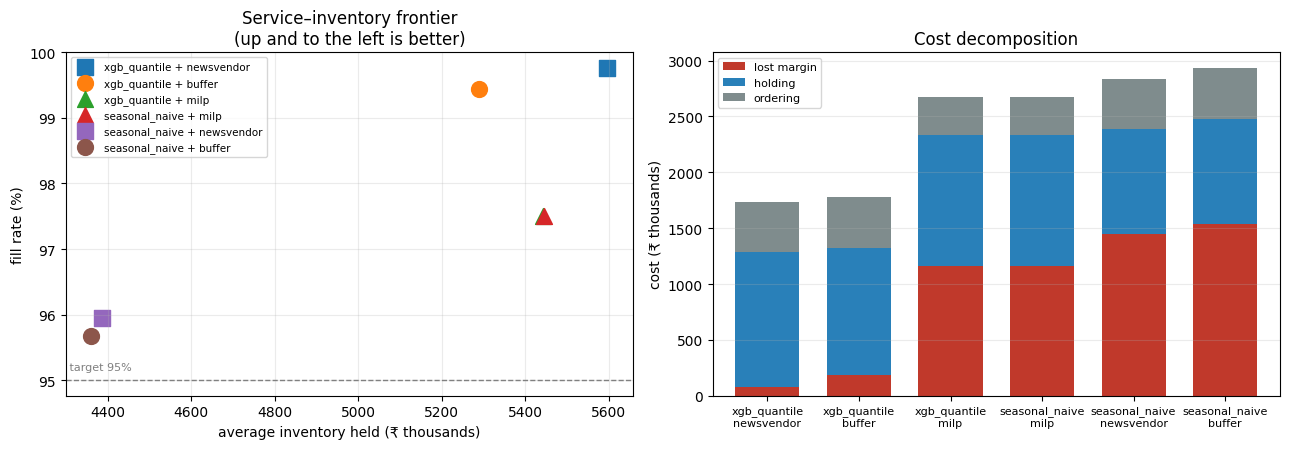

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

mk = {"buffer": "o", "newsvendor": "s", "milp": "^"}
for (f, p), row in agg.set_index(["forecaster", "policy"]).iterrows():
    ax[0].scatter(row.avg_inventory_value_inr / 1e3, row.fill_rate * 100,
                  s=130, marker=mk[p], label=f"{f} + {p}")
ax[0].axhline(CFG.target_fill_rate * 100, ls="--", c="grey", lw=1)
ax[0].text(ax[0].get_xlim()[0], CFG.target_fill_rate * 100 + 0.15,
           f" target {CFG.target_fill_rate:.0%}", color="grey", fontsize=8)
ax[0].set_xlabel("average inventory held (₹ thousands)")
ax[0].set_ylabel("fill rate (%)")
ax[0].set_title("Service–inventory frontier\n(up and to the left is better)")
ax[0].legend(fontsize=7.5)
ax[0].grid(alpha=0.25)

cost = agg.set_index(agg.forecaster + "\n" + agg.policy)[["lost_margin_inr", "holding_inr", "ordering_inr"]] / 1e3
cost.plot(kind="bar", stacked=True, ax=ax[1], width=0.7,
          color=["#c0392b", "#2980b9", "#7f8c8d"])
ax[1].set_ylabel("cost (₹ thousands)")
ax[1].set_xlabel("")
ax[1].set_title("Cost decomposition")
ax[1].tick_params(axis="x", rotation=0, labelsize=8)
ax[1].legend(["lost margin", "holding", "ordering"], fontsize=8)
ax[1].grid(alpha=0.25, axis="y")

plt.tight_layout()
plt.show()

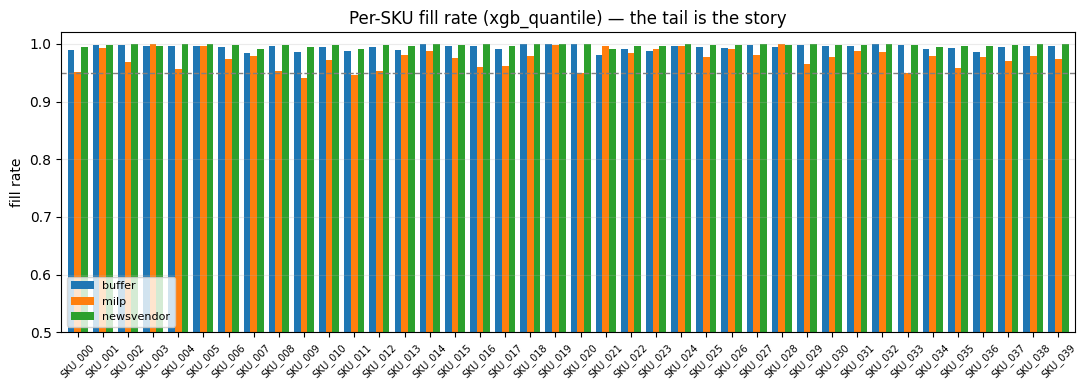

In [38]:
# Per-SKU spread — averages hide the SKUs where the policy fails.
piv = res[res.forecaster == best.forecaster].pivot(index="item_id", columns="policy", values="fill_rate")
fig, ax = plt.subplots(figsize=(11, 4))
piv.plot(kind="bar", ax=ax, width=0.8)
ax.axhline(CFG.target_fill_rate, ls="--", c="grey", lw=1)
ax.set_ylabel("fill rate"); ax.set_xlabel("")
ax.set_ylim(min(0.5, piv.min().min() - 0.05), 1.02)
ax.set_title(f"Per-SKU fill rate ({best.forecaster}) — the tail is the story")
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.legend(fontsize=8); ax.grid(alpha=0.25, axis="y")
plt.tight_layout(); plt.show()

In [39]:
res.to_csv("s1_results_by_sku.csv", index=False)
agg.to_csv("s1_results_summary.csv", index=False)
print("wrote s1_results_by_sku.csv, s1_results_summary.csv")

wrote s1_results_by_sku.csv, s1_results_summary.csv
